In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Nat_Gas.csv')
df['Prices'] = pd.to_numeric(df['Prices'], errors='coerce')
df['Dates'] = pd.to_datetime(df['Dates'], errors='coerce')
#print (df)

Sample Overview

In [4]:
print(f"Total: {len(df)}")
print(f"Date range: {df['Dates'].min()}-{df['Dates'].max()}")
print(f"Price range: ${df['Prices'].min()}-${df['Prices'].max()}")
print(f"Average Price: ${df['Prices'].mean():,.0f}")

Total: 48
Date range: 2020-10-31 00:00:00-2024-09-30 00:00:00
Price range: $9.84-$12.8
Average Price: $11


Plot

In [5]:
start_date = df['Dates'].min()
df['days_since'] = (df['Dates'] - start_date) / np.timedelta64(1, 'D')
X = df['days_since']
y = df['Prices']
#print(X)


<function matplotlib.pyplot.show(close=None, block=None)>

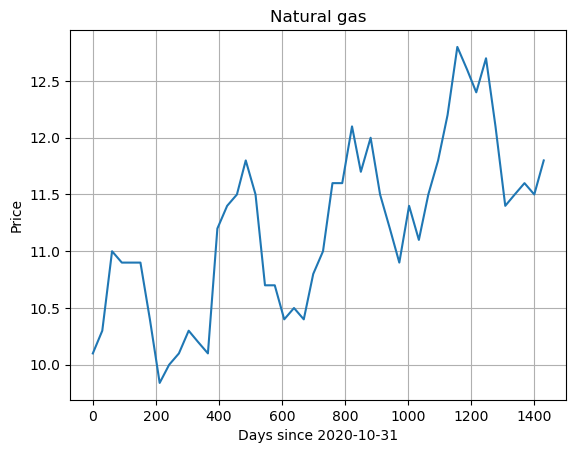

In [6]:
plt.title("Natural gas")
plt.xlabel("Days since 2020-10-31")
plt.ylabel("Price")
plt.grid(True)

plt.plot(X, y)
plt.show

Polynomial regression

In [7]:
X = np.array(df['days_since']).reshape(-1,1)
y = np.array(df['Prices']).reshape(-1,1)

def poly_features(X, K):
    X = X.flatten()
    N = X.shape[0]
    Phi = np.zeros((N, K+1))
    for k in range(K+1):
        Phi[:, k] = X**k
    return Phi

def nonlinear_features_maximum_likelihood(Phi, y):
    kappa = 1e-08
    D = Phi.shape[1]  
    theta_ml = np.linalg.inv(Phi.T@Phi + kappa*D)@Phi.T@y
    return theta_ml

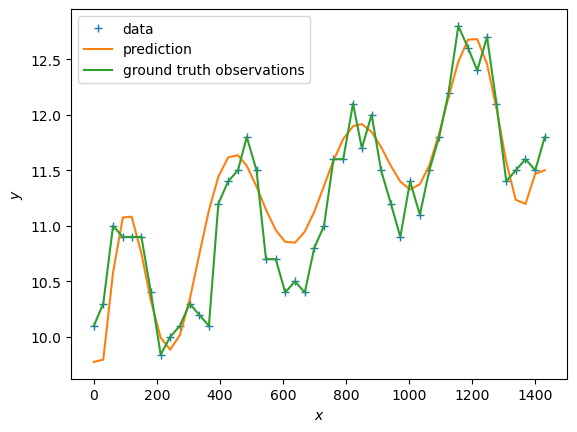

In [8]:
K = 11
Phi_1 = poly_features(X, K)
theta_ml = nonlinear_features_maximum_likelihood(Phi_1, y)
y_pred = Phi_1 @ theta_ml

plt.figure()
plt.plot(X, y, '+')
plt.plot(X, y_pred)
plt.plot(X, y)
plt.legend(["data", "prediction", "ground truth observations"])
plt.xlabel("$x$")
plt.ylabel("$y$");

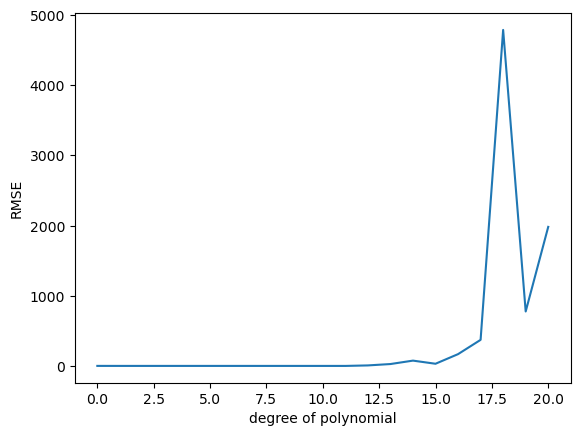

In [9]:
def RMSE(y, ypred):
    N = y.shape[0]
    rmse = np.sqrt((1/N) * np.sum((y - ypred)**2))
    return rmse

K_max = 20
rmse_train = np.zeros((K_max+1,))

for k in range(K_max+1):
    Phi = poly_features(X, k)
    theta_ml = nonlinear_features_maximum_likelihood(Phi, y)
    y_pred = Phi @ theta_ml
    rmse_train[k] = RMSE(y, y_pred)
        

plt.figure()
plt.plot(rmse_train)
plt.xlabel("degree of polynomial")
plt.ylabel("RMSE");

Polynomial/sinusodal regresion

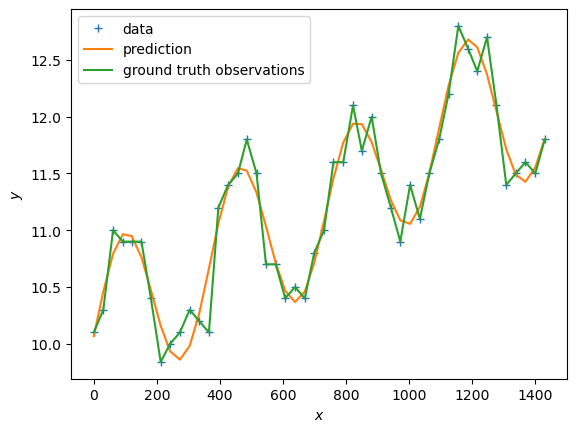

In [10]:
def polysin_features(X, K):
    X = X.flatten()
    N = X.shape[0]
    Phi = np.zeros((N, K+3))  # K+1 polynomial columns + 2 trig columns

    for k in range(K+1):
        Phi[:, k] = X**k
    
    Phi[:, K+1] = np.sin((2*np.pi*X)/365)
    Phi[:, K+2] = np.cos((2*np.pi*X)/365)
    
    return Phi

K = 9
Phi_2 = polysin_features(X, K)
theta_ml = nonlinear_features_maximum_likelihood(Phi_2, y)
y_pred_polysin = Phi_2 @ theta_ml

plt.figure()
plt.plot(X, y, '+')
plt.plot(X, y_pred_polysin)
plt.plot(X, y)
plt.legend(["data", "prediction", "ground truth observations"])
plt.xlabel("$x$")
plt.ylabel("$y$");


test the performance of the two methods on training data

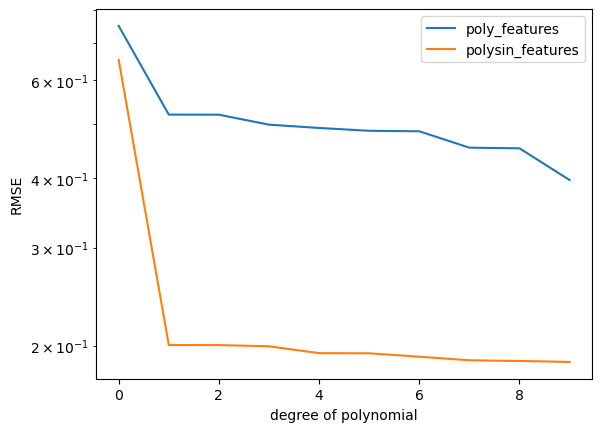

In [11]:
K_max = 9 # this is the maximum degree of polynomial we will consider
assert(K_max < 20) # this is the latest point when we'll run into numerical problems

rmse_poly = np.zeros((K_max+1,))
rmse_polysin = np.zeros((K_max+1,))

for k in range(K_max+1):
    Phi_1 = poly_features(X, k)
    Phi_2 = polysin_features(X, k)
    theta_1 = nonlinear_features_maximum_likelihood(Phi_1,y)
    theta_2 = nonlinear_features_maximum_likelihood(Phi_2, y)

    y_pred_poly = Phi_1@theta_1
    y_pred_polysin = Phi_2@theta_2
    

    rmse_poly[k] = RMSE(y,y_pred_poly)
    rmse_polysin[k] = RMSE(y,y_pred_polysin)

plt.figure()
plt.semilogy(rmse_poly)
plt.semilogy(rmse_polysin)
plt.xlabel("degree of polynomial")
plt.ylabel("RMSE")
plt.legend(["poly_features", "polysin_features"])

poly-sin feature matrix is a drastic improvement, will use to extrapolate future prices

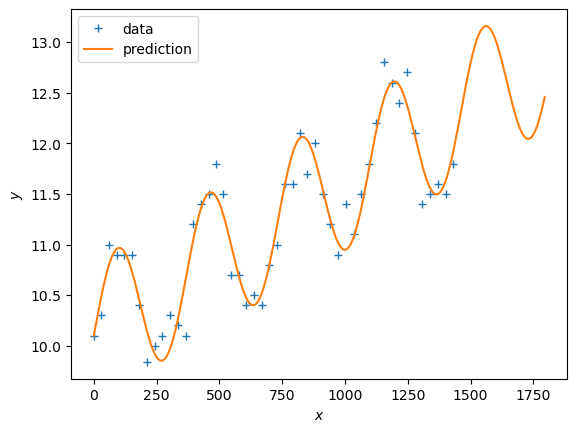

In [32]:
#max_example = np.max(X)
#print(max_example)
Xtest = np.linspace(0, 1430+365, 200).reshape(-1, 1)
K = 1 # best so far
Phi = polysin_features(X, K)
theta = nonlinear_features_maximum_likelihood(Phi,y)

Phi_test = polysin_features(Xtest, K)
y_pred = Phi_test@theta

plt.figure()
plt.plot(X, y, '+')
plt.plot(Xtest, y_pred)
plt.legend(["data", "prediction"])
plt.xlabel("$x$")
plt.ylabel("$y$");

Servicable for predictions but will try an RNN approach as well